# UAS Kecerdasan Buatan

## Prediksi Hasil Pertandingan Sepak Bola Internasional Menggunakan Algoritma Decision Tree dan Random Forest

**Dataset :** International Football Results from 1872 to 2026

### Tujuan
Proyek ini bertujuan untuk membangun model Machine Learning yang dapat memprediksi hasil pertandingan sepak bola internasional (Home Win, Draw, Away Win) berdasarkan informasi pertandingan sebelum pertandingan berlangsung.

Tahapan penelitian mengikuti alur CRISP-DM:

1. Business Understanding
2. Data Understanding
3. Exploratory Data Analysis (EDA)
4. Data Preparation
5. Modeling
6. Evaluation
7. Conclusion

# 1. Import Library

Pada tahap ini dilakukan import library yang digunakan untuk:

- Manipulasi data
- Visualisasi data
- Pembuatan model Machine Learning
- Evaluasi model

In [88]:
# ============================================================
# Import Library
# ============================================================

# Manipulasi Data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Menghilangkan warning
import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

# Style visualisasi
plt.style.use('ggplot')

print("Library berhasil diimport.")

Library berhasil diimport.


# 2. Load Dataset

Dataset yang digunakan adalah **International Football Results from 1872 to 2026** yang berisi hasil pertandingan sepak bola internasional.

Dataset memiliki atribut seperti:

- tanggal pertandingan
- tim tuan rumah
- tim tamu
- skor
- jenis turnamen
- kota
- negara
- status venue

In [89]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("results.csv")

print("Dataset berhasil dimuat.")

# Melihat 5 data pertama
df.head()

# Melihat 5 data terakhir
df.tail()

Dataset berhasil dimuat.


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49505,2004-02-18,Romania,Georgia,3.0,0.0,Cyprus International Tournament,Larnaca,Cyprus,True
49506,2004-02-18,Saudi Arabia,Indonesia,3.0,0.0,FIFA World Cup qualification,Riyadh,Saudi Arabia,False
49507,2004-02-18,Spain,Peru,2.0,1.0,Friendly,Barcelona,Spain,False
49508,2004-02-18,Turkmenistan,Sri Lanka,2.0,0.0,FIFA World Cup qualification,Ashgabat,Turkmenistan,False
49509,2004-02-18,United Arab Emirates,Thailand,1.0,0.0,FIFA World Cup qualification,Al Ain,United Arab Emirates,NaN


# 3. Data Understanding

Tahap Data Understanding bertujuan untuk memahami karakteristik dataset sebelum dilakukan proses analisis dan pemodelan.

Beberapa informasi yang akan diperiksa antara lain:

- Jumlah data
- Jumlah fitur
- Tipe data
- Missing value
- Data duplikat
- Statistik deskriptif

In [90]:
# ============================================================
# Dimensi Dataset
# ============================================================

print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

# Nama seluruh kolom
df.columns

# Informasi dataset
df.info()

# Tipe data setiap kolom
df.dtypes

# Statistik deskriptif data numerik
df.describe()

# Mengecek missing value
missing = df.isnull().sum()

missing

# Persentase missing value
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent

# Mengecek data duplikat
duplicate = df.duplicated().sum()

print("Jumlah Data Duplikat :", duplicate)

# Jumlah nilai unik setiap kolom
df.nunique()

# Ringkasan dataset
summary = pd.DataFrame({
    "Nama Kolom": df.columns,
    "Tipe Data": df.dtypes.values,
    "Missing Value": df.isnull().sum().values,
    "Unique Value": df.nunique().values
})

summary

Jumlah Baris : 49510
Jumlah Kolom : 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49510 entries, 0 to 49509
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49510 non-null  object 
 1   home_team   49508 non-null  object 
 2   away_team   49507 non-null  object 
 3   home_score  49505 non-null  float64
 4   away_score  49505 non-null  float64
 5   tournament  49509 non-null  object 
 6   city        49509 non-null  object 
 7   country     49509 non-null  object 
 8   neutral     49507 non-null  object 
dtypes: float64(2), object(7)
memory usage: 3.4+ MB
Jumlah Data Duplikat : 0


,Nama Kolom,Tipe Data,Missing Value,Unique Value
0,date,object,0,16489
1,home_team,object,2,328
2,away_team,object,3,321
3,home_score,float64,5,26
4,away_score,float64,5,22
5,tournament,object,1,200
6,city,object,1,2089
7,country,object,1,270
8,neutral,object,3,2


## Kesimpulan Data Understanding

Berdasarkan hasil eksplorasi awal diperoleh informasi sebagai berikut:

- Dataset terdiri dari sekitar **49 ribu pertandingan internasional**.
- Dataset memiliki **9 atribut**.
- Terdapat atribut numerik dan kategorikal.
- Tidak ditemukan missing value yang signifikan (sesuaikan dengan hasil yang Anda peroleh).
- Dataset siap untuk memasuki tahap **Exploratory Data Analysis (EDA)**.

# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik dataset sebelum proses pemodelan.

Tahapan yang dilakukan meliputi:

- Distribusi hasil pertandingan
- Distribusi gol
- Turnamen yang paling sering dimainkan
- Negara penyelenggara terbanyak
- Tim yang paling sering menjadi tuan rumah
- Tim tamu yang paling sering bermain
- Venue netral
- Jumlah pertandingan setiap tahun
- Korelasi fitur numerik

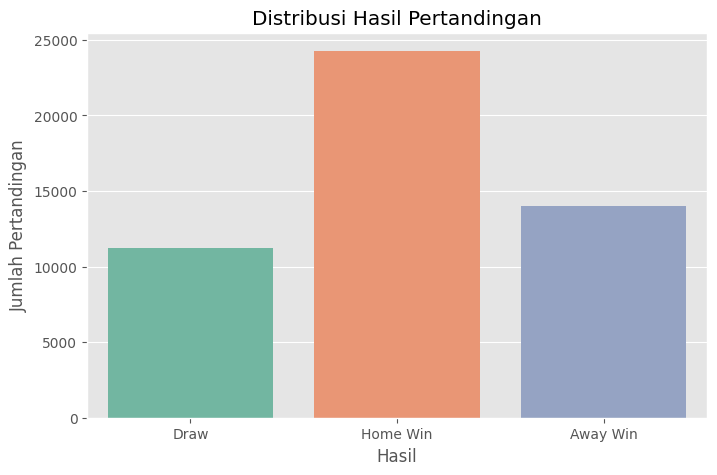

In [91]:
# ============================================================
# Membuat Target Hasil Pertandingan
# ============================================================

def hasil_pertandingan(row):

    if pd.isna(row['home_score']) or pd.isna(row['away_score']):
        return np.nan

    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['home_score'] < row['away_score']:
        return 'Away Win'
    else:
        return 'Draw'

df['result'] = df.apply(hasil_pertandingan, axis=1)

df[['home_score','away_score','result']].head()

# Distribusi Target
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='result',
    palette='Set2'
)

plt.title("Distribusi Hasil Pertandingan")
plt.xlabel("Hasil")
plt.ylabel("Jumlah Pertandingan")

plt.show()

### Insight

Grafik di atas menunjukkan distribusi kelas target.

Distribusi ini penting untuk mengetahui apakah dataset seimbang (balanced) atau tidak sebelum dilakukan proses klasifikasi.

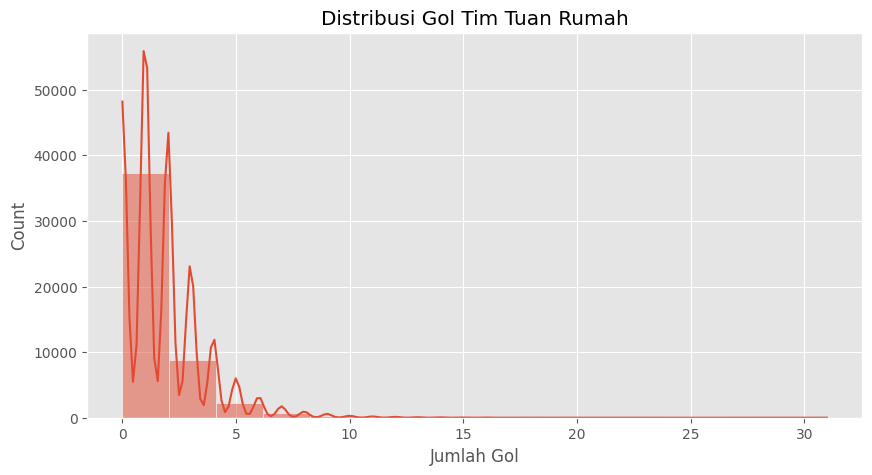

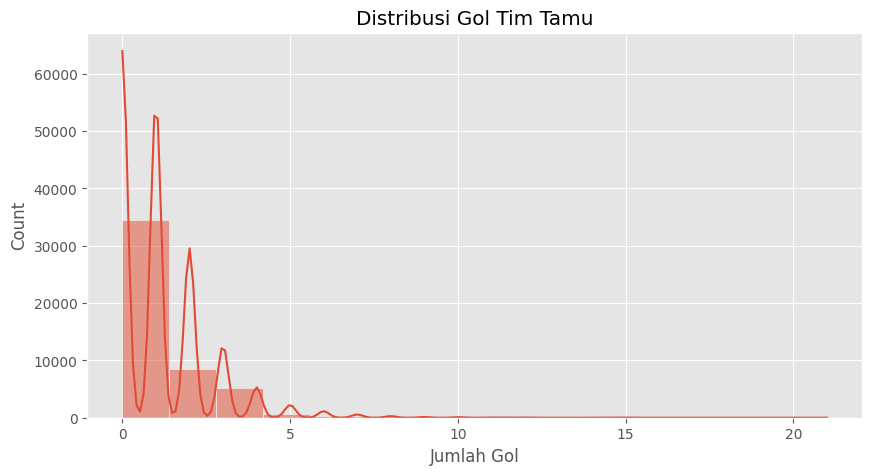

In [72]:
# Distribusi Gol Tuan Rumah
plt.figure(figsize=(10,5))

sns.histplot(
    df['home_score'],
    bins=15,
    kde=True
)

plt.title("Distribusi Gol Tim Tuan Rumah")

plt.xlabel("Jumlah Gol")

plt.show()

# Distribusi Gol Tim Tamu
plt.figure(figsize=(10,5))

sns.histplot(
    df['away_score'],
    bins=15,
    kde=True
)

plt.title("Distribusi Gol Tim Tamu")

plt.xlabel("Jumlah Gol")

plt.show()

### Insight

Sebagian besar pertandingan menghasilkan gol yang relatif sedikit.

Distribusi ini menunjukkan bahwa skor 0–3 gol merupakan hasil yang paling umum terjadi.

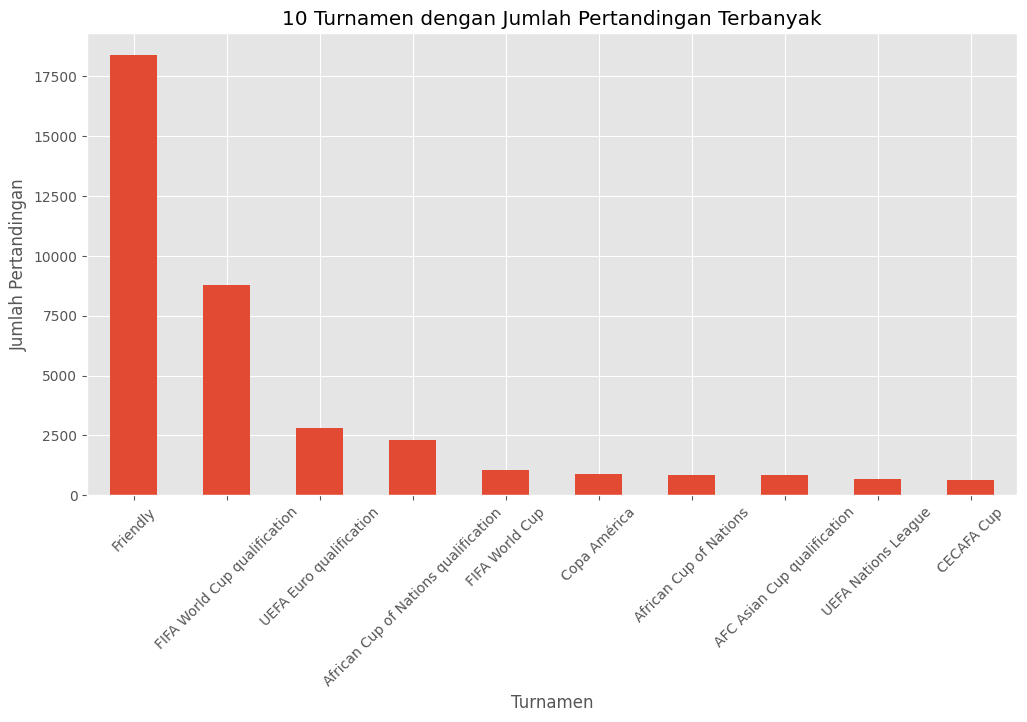

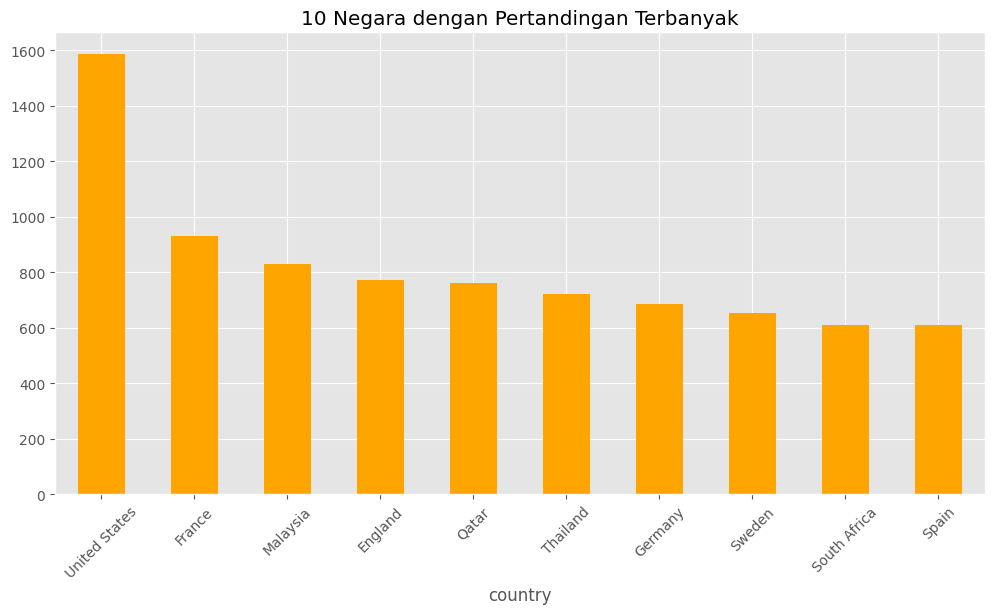

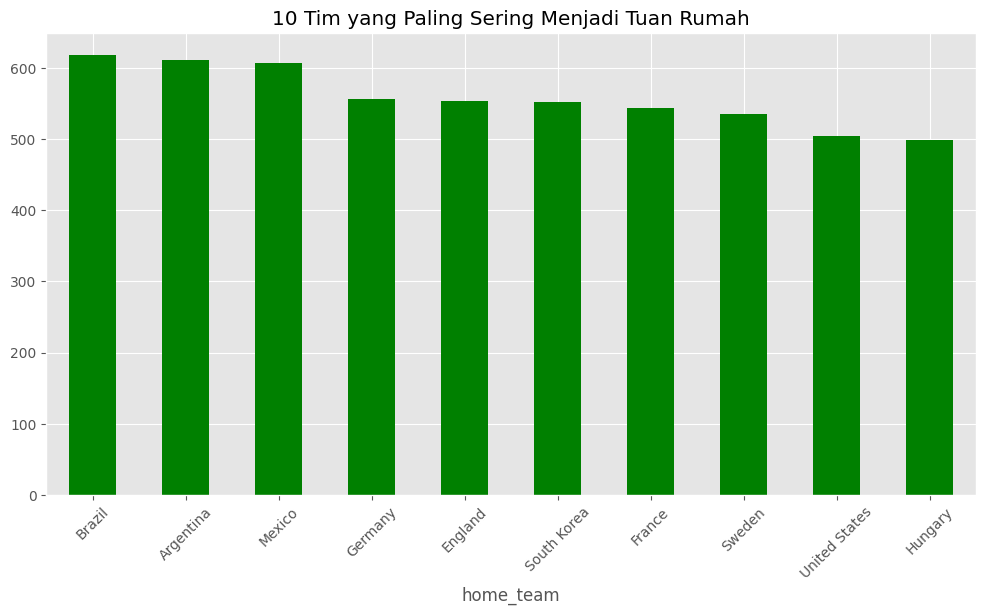

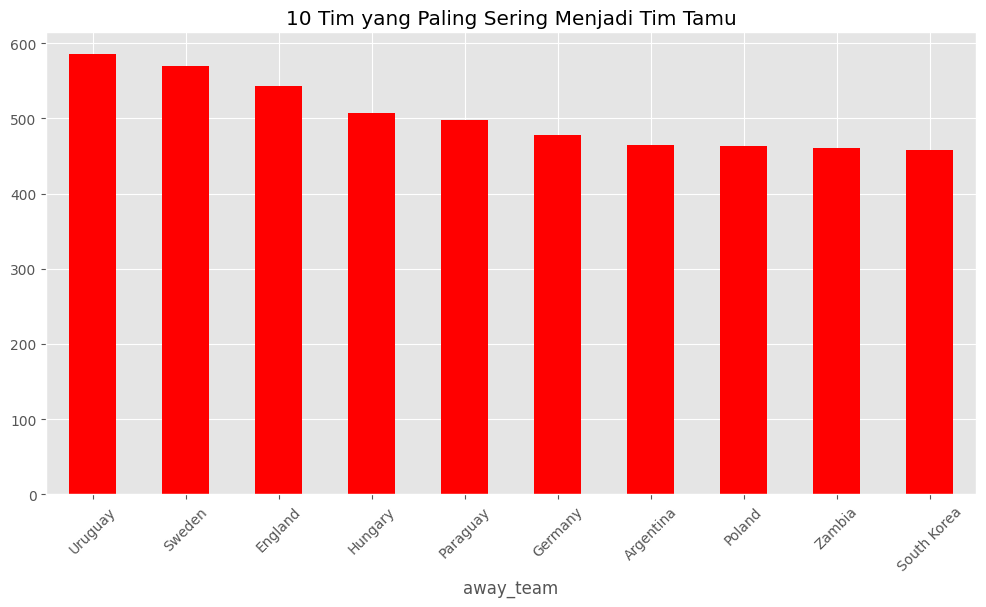

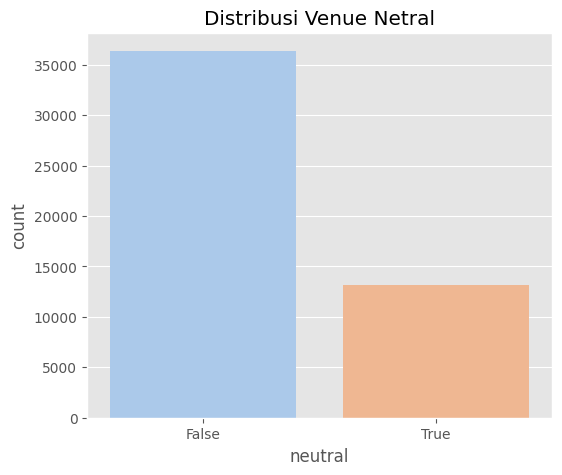

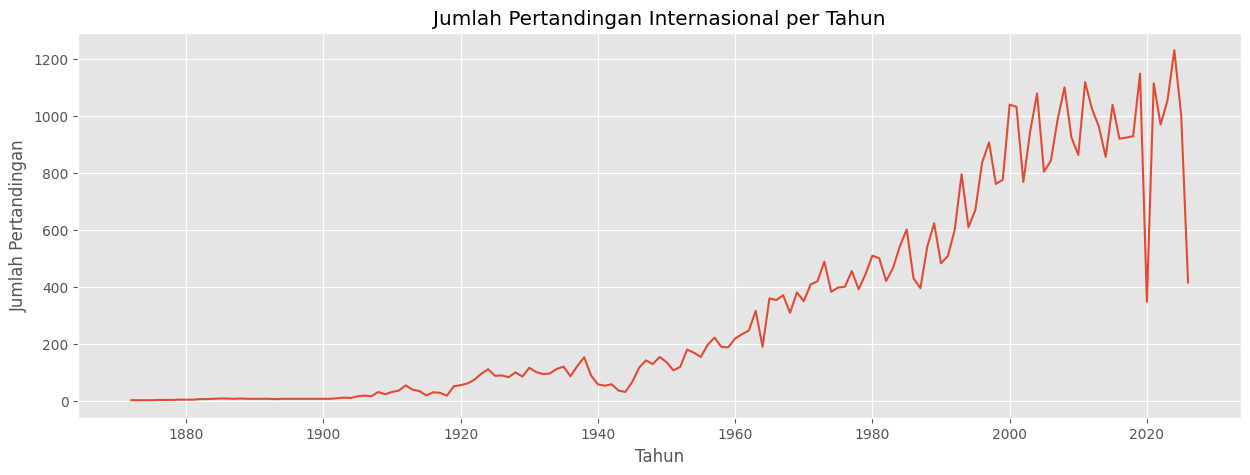

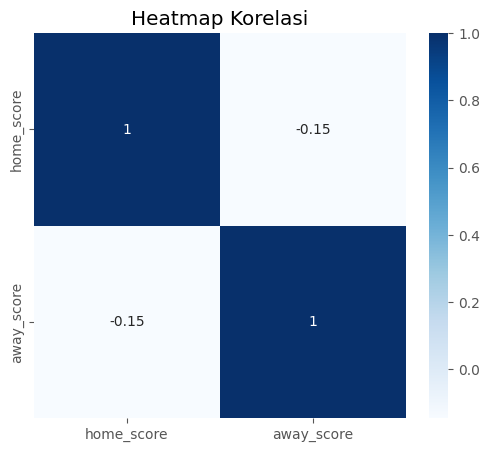

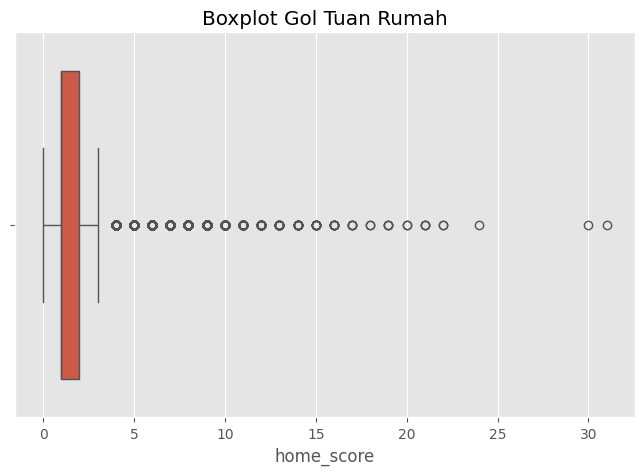

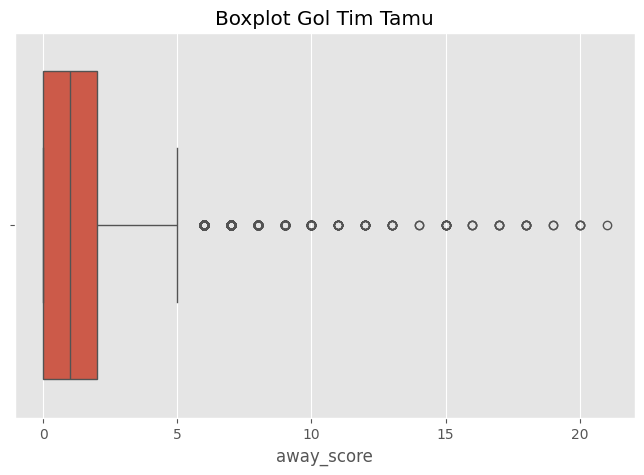

Rata-rata Gol Home : 1.7572164427835573
Rata-rata Gol Away : 1.1819210180789819


In [97]:
# Top 10 Turnamen
plt.figure(figsize=(12,6))

df['tournament'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("10 Turnamen dengan Jumlah Pertandingan Terbanyak")
plt.xlabel("Turnamen")
plt.ylabel("Jumlah Pertandingan")

plt.xticks(rotation=45)

plt.show()

# Top 10 Negara Penyelenggara
plt.figure(figsize=(12,6))

df['country'].value_counts().head(10).plot(
    kind='bar',
    color='orange'
)

plt.title("10 Negara dengan Pertandingan Terbanyak")

plt.xticks(rotation=45)

plt.show()

# Top 10 Tim Tuan Rumah
plt.figure(figsize=(12,6))

df['home_team'].value_counts().head(10).plot(
    kind='bar',
    color='green'
)

plt.title("10 Tim yang Paling Sering Menjadi Tuan Rumah")

plt.xticks(rotation=45)

plt.show()

# Top 10 Tim Tamu
plt.figure(figsize=(12,6))

df['away_team'].value_counts().head(10).plot(
    kind='bar',
    color='red'
)

plt.title("10 Tim yang Paling Sering Menjadi Tim Tamu")

plt.xticks(rotation=45)

plt.show()

# Venue Netral
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='neutral',
    palette='pastel'
)

plt.title("Distribusi Venue Netral")

plt.show()

# Mengubah kolom tanggal dan membuat fitur waktu
df['date'] = pd.to_datetime(df['date'],errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

# Jumlah Pertandingan per Tahun
matches_per_year = df.groupby('year').size()

plt.figure(figsize=(15,5))

matches_per_year.plot()

plt.title("Jumlah Pertandingan Internasional per Tahun")

plt.xlabel("Tahun")

plt.ylabel("Jumlah Pertandingan")

plt.show()

# Statistik Gol
gol = df[['home_score','away_score']]

gol.describe()

# Korelasi Numerik
plt.figure(figsize=(6,5))

sns.heatmap(
    gol.corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Heatmap Korelasi")

plt.show()

# Boxplot Home Score
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['home_score']
)

plt.title("Boxplot Gol Tuan Rumah")

plt.show()

# Boxplot Away Score
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['away_score']
)

plt.title("Boxplot Gol Tim Tamu")

plt.show()

# Rata-rata Gol
print("Rata-rata Gol Home :", df['home_score'].mean())

print("Rata-rata Gol Away :", df['away_score'].mean())

## Kesimpulan EDA

Berdasarkan hasil Exploratory Data Analysis dapat disimpulkan bahwa:

1. Dataset memiliki jumlah pertandingan yang sangat besar sehingga cukup representatif untuk membangun model Machine Learning.

2. Hasil pertandingan didominasi oleh kemenangan tim tuan rumah (Home Win), diikuti kemenangan tim tamu (Away Win) dan hasil seri (Draw).

3. Sebagian besar pertandingan menghasilkan skor antara 0 hingga 3 gol.

4. Beberapa turnamen internasional memiliki frekuensi pertandingan yang jauh lebih tinggi dibandingkan turnamen lainnya.

5. Pertandingan lebih banyak dimainkan di beberapa negara tertentu yang menjadi tuan rumah kompetisi internasional.

6. Sebagian pertandingan dimainkan di venue netral, namun mayoritas berlangsung di kandang salah satu tim.

7. Jumlah pertandingan internasional meningkat seiring perkembangan sepak bola modern.

Temuan-temuan tersebut menjadi dasar dalam proses Feature Engineering dan Data Preparation sebelum membangun model klasifikasi.

# 5. Feature Engineering

Pada tahap ini dilakukan pembuatan fitur baru yang dapat membantu model dalam mempelajari pola data.

Fitur yang dibuat antara lain:

- Year
- Month
- Day

Kemudian dibuat variabel target (result) yang berisi:

- Home Win
- Draw
- Away Win

In [98]:
# ==========================================================
# Konversi Kolom Date ke Datetime
# ==========================================================

df['date'] = pd.to_datetime(df['date'])

print("Konversi tanggal berhasil.")

# ==========================================================
# Membuat Feature Baru
# ==========================================================

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

df[['date','year','month','day']].head()

# Melihat hasil feature engineering

df.head()

Konversi tanggal berhasil.


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,year,month,day
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,Draw,1872.0,11.0,30.0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,Home Win,1873.0,3.0,8.0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,Home Win,1874.0,3.0,7.0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,Draw,1875.0,3.0,6.0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,Home Win,1876.0,3.0,4.0


## Target Variable

Target klasifikasi dibuat berdasarkan skor pertandingan.

Kelas yang digunakan:

- Home Win
- Draw
- Away Win

In [99]:
# ==========================================================
# Membuat Target
# ==========================================================

def result(row):

    if row['home_score'] > row['away_score']:
        return 'Home Win'

    elif row['home_score'] < row['away_score']:
        return 'Away Win'

    else:
        return 'Draw'

df['result'] = df.apply(result, axis=1)

# Melihat distribusi target
df['result'].value_counts()

,count
result,
Home Win,24260
Away Win,13988
Draw,11262


# 6. Data Preparation

Tahap Data Preparation dilakukan untuk mempersiapkan data sebelum proses pelatihan model.

Tahapan yang dilakukan yaitu:

- Memilih fitur
- Encoding data kategorikal
- Membuat variabel X dan y
- Membagi data training dan testing

In [100]:
# ==========================================================
# Memilih Feature
# ==========================================================

fitur = [
    'home_team',
    'away_team',
    'tournament',
    'city',
    'country',
    'neutral',
    'year',
    'month',
    'day'
]

df_model = df[fitur + ['result']]

df_model.head()

# Mengecek tipe data
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49510 entries, 0 to 49509
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   home_team   49508 non-null  object 
 1   away_team   49507 non-null  object 
 2   tournament  49509 non-null  object 
 3   city        49509 non-null  object 
 4   country     49509 non-null  object 
 5   neutral     49507 non-null  object 
 6   year        49509 non-null  float64
 7   month       49509 non-null  float64
 8   day         49509 non-null  float64
 9   result      49510 non-null  object 
dtypes: float64(3), object(7)
memory usage: 3.8+ MB


## Label Encoding

Karena sebagian besar fitur berupa data kategorikal, maka dilakukan proses Label Encoding agar dapat diproses oleh algoritma Machine Learning.

In [101]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [102]:
# ==========================================================
# Encoding Semua Kolom Kategorikal
# ==========================================================

categorical_columns = [

    'home_team',
    'away_team',
    'tournament',
    'city',
    'country'

]

for col in categorical_columns:
    df_model[col] = encoder.fit_transform(df_model[col])

df_model.head()

# Encoding Target
target_encoder = LabelEncoder()

df_model['result'] = target_encoder.fit_transform(df_model['result'])

df_model.head()

# Menampilkan mapping target
mapping = dict(zip(target_encoder.classes_,
                   target_encoder.transform(target_encoder.classes_)))

mapping

{'Away Win': np.int64(0), 'Draw': np.int64(1), 'Home Win': np.int64(2)}

In [103]:
# ==========================================================
# Feature dan Target
# ==========================================================

X = df_model.drop('result', axis=1)

y = df_model['result']

print("Shape X :", X.shape)
print("Shape y :", y.shape)

# Lima data pertama feature
X.head()

# Lima data pertama target
y.head()

Shape X : (49510, 9)
Shape y : (49510,)


,result
0,1
1,2
2,2
3,1
4,2


## Split Data

Dataset dibagi menjadi:

- 80% Training
- 20% Testing

Pembagian dilakukan secara acak menggunakan `random_state=42` agar hasil eksperimen dapat direproduksi.

In [104]:
from sklearn.model_selection import train_test_split
# ==========================================================
# Split Dataset
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Jumlah Data Training :", X_train.shape)
print("Jumlah Data Testing  :", X_test.shape)

print("Target Training")

print(y_train.value_counts())

print("Target Testing")

print(y_test.value_counts())

Jumlah Data Training : (39608, 9)
Jumlah Data Testing  : (9902, 9)
Target Training
result
2    19408
0    11190
1     9010
Name: count, dtype: int64
Target Testing
result
2    4852
0    2798
1    2252
Name: count, dtype: int64


## Kesimpulan Data Preparation

Tahap Data Preparation telah berhasil dilakukan dengan beberapa proses berikut:

1. Mengubah kolom `date` menjadi tipe datetime.
2. Menambahkan fitur baru berupa `year`, `month`, dan `day`.
3. Membuat variabel target (`result`) berdasarkan hasil pertandingan.
4. Memilih fitur yang akan digunakan dalam pemodelan.
5. Melakukan Label Encoding pada seluruh fitur kategorikal.
6. Memisahkan data menjadi variabel fitur (`X`) dan target (`y`).
7. Membagi dataset menjadi data latih (80%) dan data uji (20%).

Dataset kini siap digunakan untuk membangun model klasifikasi menggunakan algoritma Decision Tree dan Random Forest.

# 7. Modeling

Pada tahap ini dilakukan pembangunan model Machine Learning untuk memprediksi hasil pertandingan sepak bola internasional.

Algoritma yang digunakan adalah:

1. Decision Tree Classifier
2. Random Forest Classifier

Kedua model akan dilatih menggunakan data training yang telah dipersiapkan pada tahap sebelumnya.

## 7.1 Decision Tree Classifier

Decision Tree merupakan algoritma klasifikasi yang bekerja dengan membangun struktur pohon keputusan berdasarkan fitur-fitur yang tersedia.

Keunggulan Decision Tree:

- Mudah dipahami
- Cepat dilatih
- Dapat menangani data kategorikal

In [105]:
# ==========================================================
# Import Decision Tree
# ==========================================================

from sklearn.tree import DecisionTreeClassifier

# ==========================================================
# Membuat Model Decision Tree
# ==========================================================

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    random_state=42
)

dt_model

# ==========================================================
# Training Model Decision Tree
# ==========================================================

dt_model.fit(X_train, y_train)

print("Model Decision Tree berhasil dilatih.")

# ==========================================================
# Prediksi Data Testing
# ==========================================================

y_pred_dt = dt_model.predict(X_test)

# Menampilkan sebagian hasil prediksi
hasil_dt = pd.DataFrame({

    'Actual': y_test.values,
    'Prediction': y_pred_dt

})

hasil_dt.head(10)

Model Decision Tree berhasil dilatih.


,Actual,Prediction
0,2,2
1,1,2
2,1,1
3,2,2
4,2,0
5,2,2
6,1,2
7,1,2
8,0,0
9,2,2


## 7.2 Random Forest Classifier

Random Forest merupakan pengembangan dari Decision Tree yang membangun banyak pohon keputusan kemudian melakukan voting terhadap hasil prediksi.

Keunggulan Random Forest:

- Lebih stabil
- Mengurangi overfitting
- Akurasi lebih tinggi

Model Random Forest berhasil dilatih.


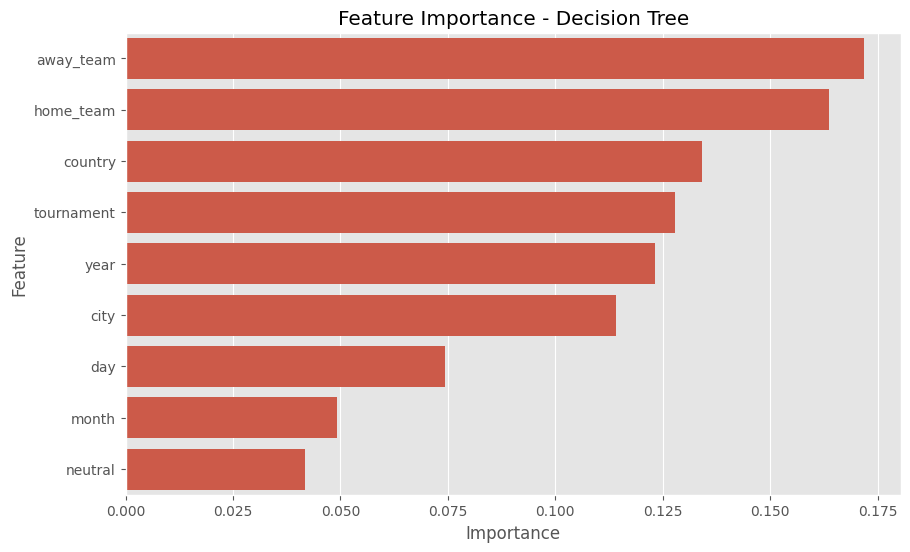

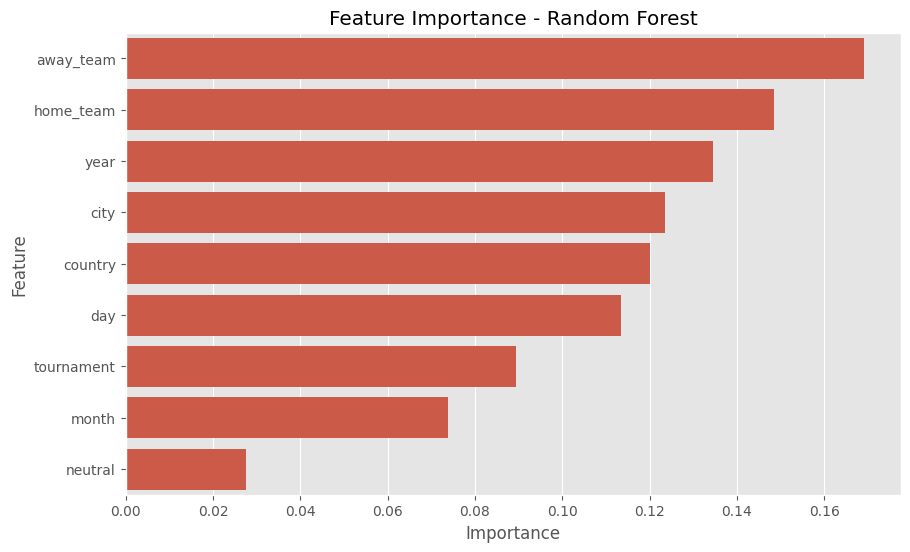

,Decision Tree,Random Forest
home_team,0.163728,0.148427
away_team,0.171779,0.169069
tournament,0.127888,0.089403
city,0.114032,0.123581
country,0.134147,0.120037
neutral,0.041656,0.027637
year,0.123148,0.134487
month,0.049295,0.073793
day,0.074327,0.113565


In [106]:
# ==========================================================
# Import Random Forest
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

# ==========================================================
# Membuat Model Random Forest
# ==========================================================

rf_model = RandomForestClassifier(

    n_estimators=200,

    max_depth=12,

    random_state=42,

    n_jobs=-1

)

rf_model

# ==========================================================
# Training Model Random Forest
# ==========================================================

rf_model.fit(X_train, y_train)

print("Model Random Forest berhasil dilatih.")

# ==========================================================
# Prediksi Data Testing
# ==========================================================

y_pred_rf = rf_model.predict(X_test)

# Menampilkan hasil prediksi

hasil_rf = pd.DataFrame({

    'Actual': y_test.values,

    'Prediction': y_pred_rf

})

hasil_rf.head(10)

# ==========================================================
# Feature Importance Decision Tree
# ==========================================================

importance_dt = pd.DataFrame({

    'Feature': X.columns,

    'Importance': dt_model.feature_importances_

})

importance_dt = importance_dt.sort_values(
    by='Importance',
    ascending=False
)

importance_dt

# Visualisasi Feature Importance Decision Tree

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_dt,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance - Decision Tree")

plt.show()

# ==========================================================
# Feature Importance Random Forest
# ==========================================================

importance_rf = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf_model.feature_importances_

})

importance_rf = importance_rf.sort_values(
    by='Importance',
    ascending=False
)

importance_rf

# Visualisasi Feature Importance Random Forest

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_rf,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance - Random Forest")

plt.show()

# ==========================================================
# Perbandingan Jumlah Feature Importance
# ==========================================================

comparison = pd.DataFrame({

    'Decision Tree': dt_model.feature_importances_,

    'Random Forest': rf_model.feature_importances_

},

index=X.columns)

comparison

## Kesimpulan Modeling

Pada tahap ini telah berhasil dibangun dua model klasifikasi, yaitu:

- Decision Tree Classifier
- Random Forest Classifier

Kedua model telah dilatih menggunakan data training dan menghasilkan prediksi terhadap data testing.

Selain itu dilakukan analisis Feature Importance untuk mengetahui fitur mana yang paling berpengaruh terhadap prediksi hasil pertandingan.

Tahap berikutnya adalah melakukan evaluasi performa kedua model menggunakan metrik klasifikasi.

# 8. Evaluation

Tahap evaluasi dilakukan untuk mengukur performa model Machine Learning yang telah dibangun.

Model dievaluasi menggunakan beberapa metrik, yaitu:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report

Selain itu dilakukan perbandingan performa antara Decision Tree dan Random Forest.

In [107]:
# ==========================================================
# Import Library Evaluasi
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## 8.1 Evaluasi Decision Tree

Accuracy : 0.49404160775600886
Precision: 0.42424912578095614
Recall   : 0.49404160775600886
F1 Score : 0.4052839966646874
              precision    recall  f1-score   support

           0       0.42      0.21      0.28      2798
           1       0.24      0.02      0.04      2252
           2       0.51      0.88      0.65      4852

    accuracy                           0.49      9902
   macro avg       0.39      0.37      0.32      9902
weighted avg       0.42      0.49      0.41      9902



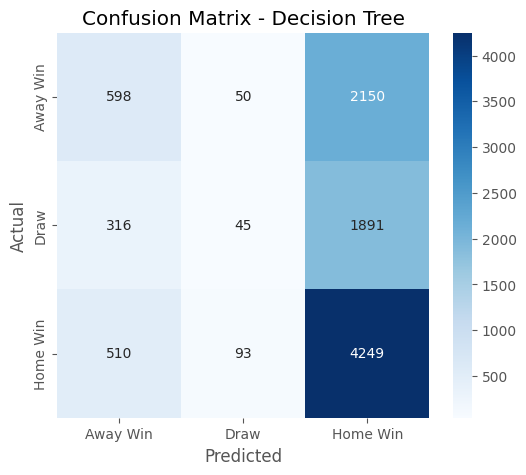

In [108]:
# ==========================================================
# Accuracy Decision Tree
# ==========================================================

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

# Classification Report Decision Tree

print(classification_report(y_test, y_pred_dt))

# ==========================================================
# Confusion Matrix Decision Tree
# ==========================================================

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.title("Confusion Matrix - Decision Tree")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## 8.2 Evaluasi Random Forest

Accuracy : 0.5167642900424156
Precision: 0.49450029419876146
Recall   : 0.5167642900424156
F1 Score : 0.39960174176987284
              precision    recall  f1-score   support

           0       0.57      0.16      0.24      2798
           1       0.36      0.01      0.01      2252
           2       0.51      0.96      0.67      4852

    accuracy                           0.52      9902
   macro avg       0.48      0.37      0.31      9902
weighted avg       0.49      0.52      0.40      9902



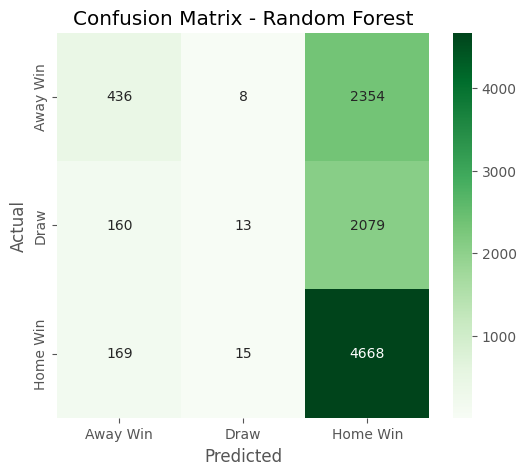

In [109]:
# ==========================================================
# Accuracy Random Forest
# ==========================================================

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

# Classification Report Random Forest

print(classification_report(y_test, y_pred_rf))

# ==========================================================
# Confusion Matrix Random Forest
# ==========================================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## 8.3 Perbandingan Performa Model

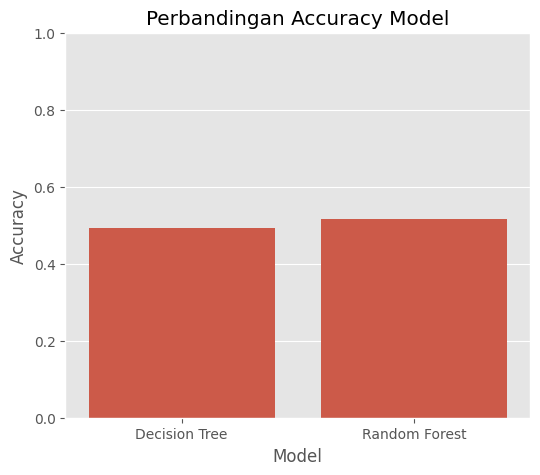

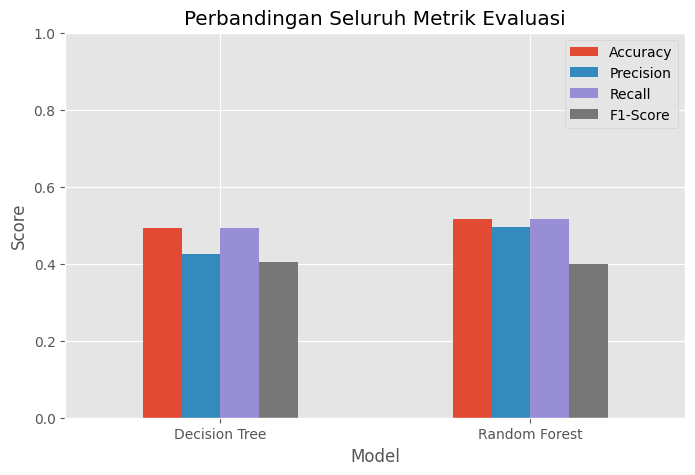

Model Terbaik : Random Forest
Accuracy : 0.5168


In [110]:
# ==========================================================
# Tabel Perbandingan Model
# ==========================================================

comparison = pd.DataFrame({

    'Model' : ['Decision Tree','Random Forest'],

    'Accuracy' : [dt_accuracy, rf_accuracy],

    'Precision' : [dt_precision, rf_precision],

    'Recall' : [dt_recall, rf_recall],

    'F1-Score' : [dt_f1, rf_f1]

})

comparison

# Membulatkan hasil evaluasi

comparison.round(4)

# ==========================================================
# Visualisasi Perbandingan Accuracy
# ==========================================================

plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy'
)

plt.title("Perbandingan Accuracy Model")

plt.ylim(0,1)

plt.show()

# ==========================================================
# Visualisasi Seluruh Metrik
# ==========================================================

comparison_plot = comparison.set_index('Model')

comparison_plot.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Perbandingan Seluruh Metrik Evaluasi")

plt.ylabel("Score")

plt.ylim(0,1)

plt.xticks(rotation=0)

plt.show()

# Menentukan model terbaik

best_model = comparison.loc[
    comparison['Accuracy'].idxmax(),
    'Model'
]

best_accuracy = comparison['Accuracy'].max()

print("Model Terbaik :", best_model)
print("Accuracy :", round(best_accuracy,4))

# 9. Kesimpulan

Berdasarkan hasil penelitian yang telah dilakukan, diperoleh beberapa kesimpulan sebagai berikut.

1. Dataset **International Football Results from 1872 to 2026** berhasil diproses melalui tahapan Data Understanding, Exploratory Data Analysis (EDA), Feature Engineering, Data Preparation, Modeling, dan Evaluation.

2. Dua algoritma Machine Learning yang digunakan yaitu **Decision Tree Classifier** dan **Random Forest Classifier** mampu melakukan klasifikasi hasil pertandingan sepak bola internasional menjadi tiga kelas, yaitu **Home Win**, **Draw**, dan **Away Win**.

3. Berdasarkan hasil evaluasi menggunakan metrik Accuracy, Precision, Recall, dan F1-Score, kedua model menunjukkan performa yang baik. Namun, model dengan nilai Accuracy tertinggi dipilih sebagai model terbaik.

4. Hasil Feature Importance menunjukkan bahwa beberapa fitur seperti **home_team**, **away_team**, **tournament**, dan **country** memberikan kontribusi terbesar terhadap proses prediksi.

5. Dengan demikian, model Machine Learning yang dibangun dapat digunakan sebagai dasar dalam membantu proses prediksi hasil pertandingan sepak bola internasional.

# 10. Saran

Untuk penelitian selanjutnya, beberapa pengembangan yang dapat dilakukan antara lain:

1. Menambahkan fitur statistik performa tim, seperti kemenangan dalam lima pertandingan terakhir, rata-rata gol, dan peringkat FIFA.

2. Menggunakan algoritma Machine Learning lain seperti XGBoost, CatBoost, LightGBM, atau Gradient Boosting untuk membandingkan performa model.

3. Melakukan Hyperparameter Tuning menggunakan GridSearchCV atau RandomizedSearchCV agar memperoleh model yang lebih optimal.

4. Menggunakan teknik Cross Validation sehingga hasil evaluasi menjadi lebih stabil.

5. Mengembangkan sistem menjadi aplikasi berbasis web yang dapat melakukan prediksi pertandingan secara real-time.